In [ ]:
%load_ext autoreload
%autoreload 2
from pandas import DataFrame
import pandas as pd
from natnet import DataFrame as NatNetDataFrame
from optitrack_motive_connector import context  # Module-level singleton
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd


def custom_capture_config(data_frame: NatNetDataFrame, capture_label: str):
    # 예시로 위치만 추적하는 config
    return [
            {
                "label" : capture_label,
                "rigid_body_id": body.id_num,
                "x": body.pos[0],
                "y": body.pos[1],
                "z": body.pos[2],
                "tracking_valid": body.tracking_valid,
                "marker_error": body.marker_error,
            } for body in data_frame.rigid_bodies
        ]


In [ ]:

records = []    # DataFrame들을 담을 공간

context.init(
    server_ip_address= "127.0.0.1",
    local_ip_address = "127.0.0.1"
)                                                   # 기본 세팅

context.set_capture_config(custom_capture_config)   # 어떤 데이터를 수집할지

with context.connection:
    try:
        for capture_label in range(1, 50):
            
            print(f"Starting capture {capture_label}")

            capture: DataFrame = context.capture(3, f"Capture {capture_label}")   # 3초동안 기록
            output = capture.groupby(["label", "rigid_body_id"], as_index=False).agg(       # 그 3초동안 mean을 구한 데이터프레임을 저장함
                        count=("x", "count"),
                        average_x=("x", "mean"),
                        average_y=("y", "mean"),
                        average_z=("z", "mean"),

                        stdev_x=("x", "std"),
                        stdev_y=("y", "std"),
                        stdev_z=("z", "std"),
                    )
            output.insert(1, "rigid_body_name", output["rigid_body_id"].map(context.get_rigidbody_name)),
            records.append(output)
            print(output.head())
            context.sleep(2)    # 2초동안 수면 (time.sleep()하면 UDP queue 처리때문에 랙이 발생할 수 있으므로 context.sleep()하는 것이 좋습니다.)
    except KeyboardInterrupt:
        pass    

    df = pd.concat(records)
    print(df.iloc[0])
    print(df.iloc[-1])
    df.to_csv("capture.csv")

Entering connection...
NatNet 버전 4.2.0.0
 -> Connected!
Starting capture 1
Discovered rigid body: id=13, name='Camera'
Discovered rigid body: id=14, name='Chair'
       label rigid_body_name  rigid_body_id  count  average_x  average_y  \
0  Capture 1          Camera             13     61   0.502022   0.649056   
1  Capture 1           Chair             14     61  -0.206292   0.262520   

   average_z   stdev_x   stdev_y   stdev_z  
0   0.215632  0.000076  0.000261  0.000335  
1   1.081998  0.000116  0.000191  0.000584  
Starting capture 2
       label rigid_body_name  rigid_body_id  count  average_x  average_y  \
0  Capture 2          Camera             13     61   0.502050   0.649194   
1  Capture 2           Chair             14     61  -0.206221   0.262601   

   average_z   stdev_x   stdev_y   stdev_z  
0   0.215560  0.000047  0.000060  0.000061  
1   1.081927  0.000052  0.000087  0.000141  
Starting capture 3
       label rigid_body_name  rigid_body_id  count  average_x  average_y

In [20]:
df

,label,rigid_body_name,rigid_body_id,count,average_x,average_y,average_z,stdev_x,stdev_y,stdev_z
0,Capture 1,Camera,13,62,-0.482645,0.534853,0.047502,0.000031,0.000156,0.000096
1,Capture 1,Chair,14,62,-0.206338,0.262343,1.082620,0.000022,0.000048,0.000077
0,Capture 2,Camera,13,61,-0.482631,0.534849,0.047497,0.000026,0.000145,0.000093
1,Capture 2,Chair,14,61,-0.206325,0.262339,1.082619,0.000026,0.000031,0.000069
0,Capture 3,Camera,13,61,-0.482628,0.534792,0.047519,0.000032,0.000118,0.000074
...,...,...,...,...,...,...,...,...,...,...
1,Capture 47,Chair,14,61,-0.206169,0.262147,1.082140,0.000212,0.000315,0.000559
0,Capture 48,Camera,13,61,0.502122,0.648802,0.215971,0.000113,0.000226,0.000305
1,Capture 48,Chair,14,61,-0.206112,0.262298,1.082014,0.000090,0.000239,0.000429
0,Capture 49,Camera,13,62,0.502074,0.648870,0.215927,0.000102,0.000176,0.000153


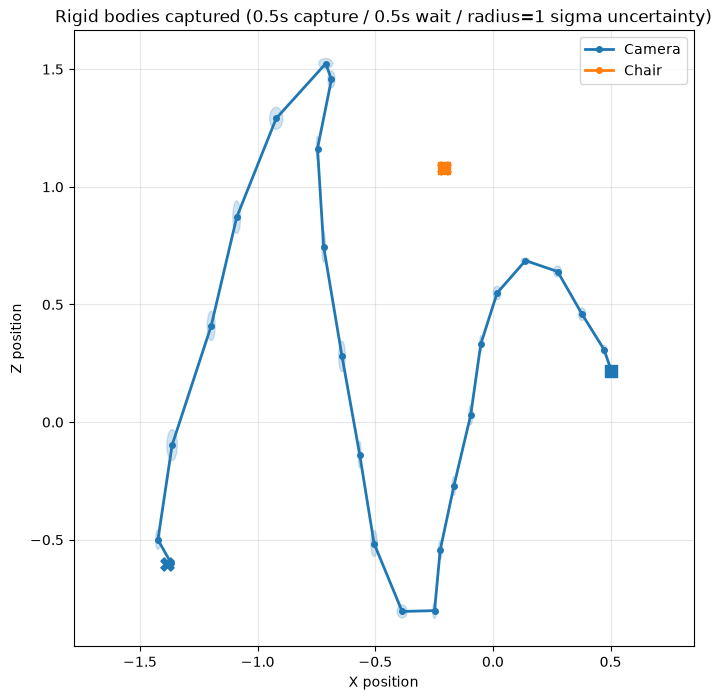

In [ ]:
## 아래 코드는 plot를 그리는 코드로 모듈과 관련이 없습니다.

def plot_paths(df: pd.DataFrame, sigma_scale: float = 1.0) -> None:
    required_columns = {
        "rigid_body_name",
        "average_x",
        "average_z",
        "stdev_x",
        "stdev_z",
    }

    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    colors = {
        "Camera": "tab:blue",
        "Chair": "tab:orange",
    }

    fig, ax = plt.subplots(figsize=(8, 8))

    for name, path in df.groupby("rigid_body_name", sort=False):
        if name not in colors:
            continue

        path = path.dropna(
            subset=["average_x", "average_z", "stdev_x", "stdev_z"]
        )

        if path.empty:
            continue

        color = colors[name]

        # Connect consecutive mean positions.
        ax.plot(
            path["average_x"],
            path["average_z"],
            color=color,
            marker="o",
            markersize=4,
            linewidth=2,
            label=name,
            zorder=3,
        )

        # Draw the standard-deviation region around each position.
        for _, row in path.iterrows():
            uncertainty = Ellipse(
                xy=(row["average_x"], row["average_z"]),
                width=2 * sigma_scale * row["stdev_x"],
                height=2 * sigma_scale * row["stdev_z"],
                facecolor=color,
                edgecolor=color,
                alpha=0.2,
                linewidth=1,
                zorder=2,
            )
            ax.add_patch(uncertainty)

        # Highlight the beginning and end of each path.
        ax.scatter(
            path["average_x"].iloc[0],
            path["average_z"].iloc[0],
            color=color,
            marker="s",
            s=70,
            zorder=4,
        )

        ax.scatter(
            path["average_x"].iloc[-1],
            path["average_z"].iloc[-1],
            color=color,
            marker="X",
            s=90,
            zorder=4,
        )

    ax.set_xlabel("X position")
    ax.set_ylabel("Z position")
    ax.set_title(f"paths")
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.title("Rigid bodies captured (0.5s capture / 0.5s wait / radius=1 sigma uncertainty)")

    plt.show()
plot_paths(df)